# VEV Options — Comprehensive Analysis

Round 3 options chain on **VELVETFRUIT_EXTRACT**.
VEV_XXXX are treated as European call options with strike = XXXX.

> Hint: *La trahison des images* — look beyond face value.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
from scipy.stats import norm
from scipy.optimize import brentq
from mpl_toolkits.mplot3d import Axes3D  # noqa
import warnings

DATA_DIR = Path("../historical_data/round_3")
STRIKES  = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VEV_COLS = [f"VEV_{k}" for k in STRIKES]
UNDERLYING = "VELVETFRUIT_EXTRACT"
days = [0, 1, 2]
day_colors = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}

# ── Load all products ──────────────────────────────────────────────
frames = []
for d in days:
    tmp = pd.read_csv(DATA_DIR / f"prices_round_3_day_{d}.csv", sep=";")
    frames.append(tmp)
raw = pd.concat(frames, ignore_index=True)

ticks_per_day = int(raw[raw["day"] == 0]["timestamp"].max() + 100)
raw["global_ts"] = (raw["day"] - days[0]) * ticks_per_day + raw["timestamp"]

# Pivot to wide: one column per product, indexed by global_ts
wide = raw.pivot_table(index="global_ts", columns="product",
                       values="mid_price", aggfunc="first")
wide = wide.sort_index().reset_index()

# Align day/timestamp info
ts_map = raw.drop_duplicates("global_ts").set_index("global_ts")[["day","timestamp"]]
wide = wide.join(ts_map, on="global_ts")

# Tick index for T estimation (0 = start, total_ticks-1 = end)
total_ticks = len(wide)
wide["tick_idx"] = np.arange(total_ticks)
wide["T"] = (total_ticks - wide["tick_idx"]) / total_ticks  # fraction of time remaining

S = wide[UNDERLYING]
print(f"Total ticks: {total_ticks}  ticks_per_day: {ticks_per_day}")
print(f"Underlying price range: {S.min():.1f} – {S.max():.1f}")
wide[[UNDERLYING] + VEV_COLS].describe().round(2)


Total ticks: 30000  ticks_per_day: 1000000
Underlying price range: 5198.0 – 5300.0


,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.0,30000.0
mean,5250.10,1250.11,750.11,255.02,166.81,95.55,46.76,15.95,6.64,0.5,0.5
std,15.63,15.65,15.64,14.38,12.74,9.66,6.23,3.43,1.74,0.0,0.0
min,5198.00,1198.00,698.50,206.50,125.00,64.00,26.50,6.50,2.50,0.5,0.5
25%,5238.50,1238.50,739.00,245.00,158.00,89.00,43.00,13.50,5.50,0.5,0.5
50%,5249.50,1249.50,749.00,254.00,166.50,96.00,47.00,16.50,6.50,0.5,0.5
75%,5262.50,1262.50,762.00,266.00,176.00,102.50,51.00,18.00,7.50,0.5,0.5
max,5300.00,1300.00,799.50,300.50,205.50,122.50,65.50,27.00,12.50,0.5,0.5


In [2]:
# ── Black-Scholes helper functions ────────────────────────────────────────────

def bs_call(S, K, T, sigma, r=0.0):
    """European call price (Black-Scholes, r=0 default)."""
    if T <= 1e-8 or sigma <= 1e-8:
        return max(float(S) - float(K), 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_delta(S, K, T, sigma, r=0.0):
    """Delta = N(d1)."""
    if T <= 1e-8 or sigma <= 1e-8:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(norm.cdf(d1))

def bs_gamma(S, K, T, sigma, r=0.0):
    """Gamma = N'(d1) / (S * sigma * sqrt(T))."""
    if T <= 1e-8 or sigma <= 1e-8:
        return 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(norm.pdf(d1) / (S * sigma * np.sqrt(T)))

def bs_vega(S, K, T, sigma, r=0.0):
    """Vega = S * N'(d1) * sqrt(T)."""
    if T <= 1e-8 or sigma <= 1e-8:
        return 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(S * norm.pdf(d1) * np.sqrt(T))

def bs_theta(S, K, T, sigma, r=0.0):
    """Theta per tick (negative = time decay)."""
    if T <= 1e-8 or sigma <= 1e-8:
        return 0.0
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return float(-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)))

def implied_vol(C, S, K, T, tol=1e-7):
    """Implied volatility via bisection (brentq). Returns NaN if unsolvable."""
    intrinsic = max(float(S) - float(K), 0.0)
    if np.isnan(C) or np.isnan(S) or T <= 1e-8:
        return np.nan
    if C <= intrinsic + tol or C >= S:
        return np.nan
    try:
        return brentq(lambda sig: bs_call(S, K, T, sig) - C,
                      1e-6, 30.0, xtol=tol, maxiter=300)
    except (ValueError, RuntimeError):
        return np.nan

print("Black-Scholes functions defined.")
# Quick sanity check
S_test, K_test, T_test, sig_test = 5250, 5200, 0.5, 0.15
C_test = bs_call(S_test, K_test, T_test, sig_test)
iv_back = implied_vol(C_test, S_test, K_test, T_test)
print(f"BS call({S_test},{K_test},T={T_test},σ={sig_test}) = {C_test:.4f}  → IV roundtrip = {iv_back:.6f}")


Black-Scholes functions defined.
BS call(5250,5200,T=0.5,σ=0.15) = 246.8862  → IV roundtrip = 0.150000


## 1 — Option Chain Snapshot

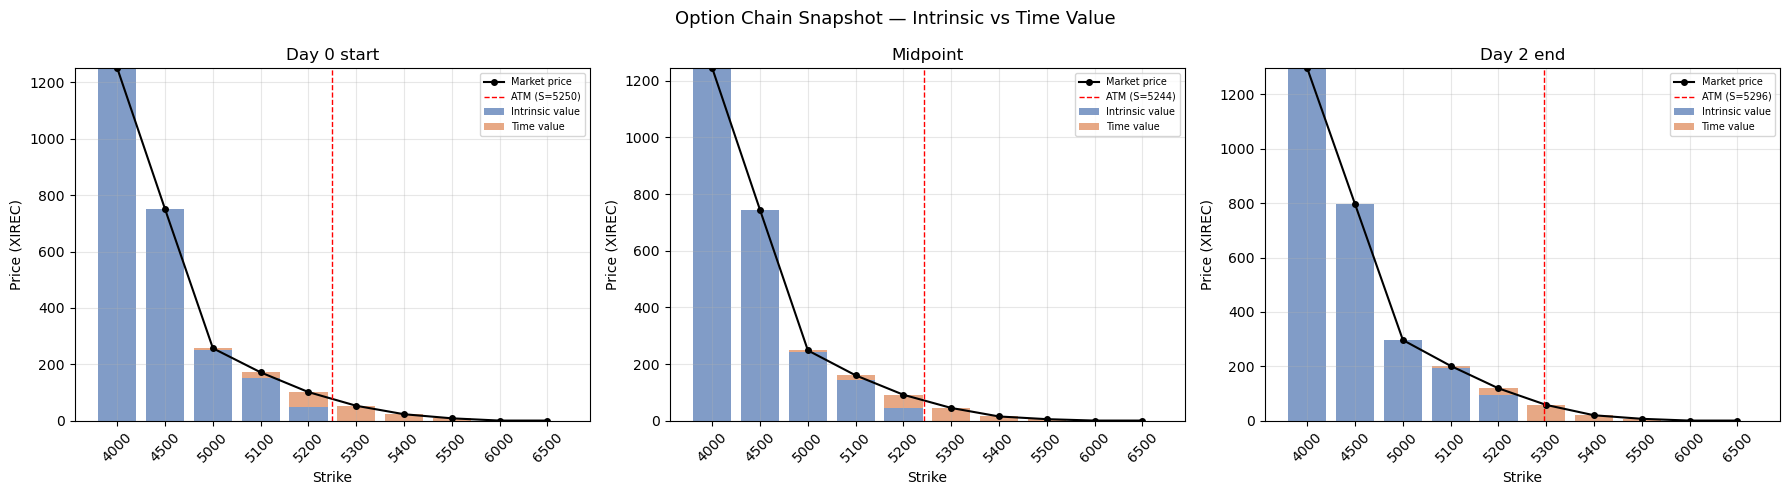

In [3]:
# Snapshots at beginning, middle, end of dataset
snap_indices = [0, total_ticks // 2, total_ticks - 1]
snap_labels  = ["Day 0 start", "Midpoint", "Day 2 end"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, idx, lbl in zip(axes, snap_indices, snap_labels):
    row = wide.iloc[idx]
    S_snap = row[UNDERLYING]
    prices = [row.get(f"VEV_{k}", np.nan) for k in STRIKES]
    intrinsic = [max(S_snap - k, 0) for k in STRIKES]
    time_val  = [max(p - iv, 0) if not np.isnan(p) else np.nan
                 for p, iv in zip(prices, intrinsic)]

    x = np.arange(len(STRIKES))
    ax.bar(x, intrinsic, label="Intrinsic value", color="#4C72B0", alpha=0.7)
    ax.bar(x, time_val, bottom=intrinsic, label="Time value", color="#DD8452", alpha=0.7)
    ax.plot(x, prices, "ko-", ms=4, lw=1.5, label="Market price")
    ax.axvline(x=np.interp(S_snap, STRIKES, x), color="red",
               ls="--", lw=1, label=f"ATM (S={S_snap:.0f})")
    ax.set_xticks(x); ax.set_xticklabels([str(k) for k in STRIKES], rotation=45)
    ax.set_title(lbl); ax.set_xlabel("Strike"); ax.set_ylabel("Price (XIREC)")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.suptitle("Option Chain Snapshot — Intrinsic vs Time Value", fontsize=13)
plt.tight_layout(); plt.show()


## 2 — Black-Scholes Primer

**Model:** $C = S \cdot N(d_1) - K \cdot N(d_2)$

where $d_1 = \frac{\ln(S/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$, $d_2 = d_1 - \sigma\sqrt{T}$

**Assumptions:** $r = 0$ (no risk-free rate in XIREC economy), $T$ = fraction of simulation ticks remaining (0→1), $\sigma$ = implied volatility in "per-sim-unit" space.

**Implied volatility (IV):** the $\sigma$ that makes the BS price equal the market price. IV encodes the market's expectation of future realised vol.

**Greeks:**
- $\Delta$ (delta): sensitivity to underlying price change
- $\Gamma$ (gamma): rate of change of delta
- $V$ (vega): sensitivity to volatility change
- $\Theta$ (theta): time decay per tick

## 3 — Implied Volatility Engine

In [4]:
# Compute implied volatility for every tick × strike
print("Computing implied volatilities (this may take ~30s)…")
iv_df = pd.DataFrame(index=wide.index)
iv_df["global_ts"] = wide["global_ts"]
iv_df["day"]       = wide["day"]
iv_df["T"]         = wide["T"]

for K in STRIKES:
    col = f"VEV_{K}"
    if col not in wide.columns:
        iv_df[f"IV_{K}"] = np.nan
        continue
    ivs = []
    for _, row in wide.iterrows():
        C_val = row.get(col, np.nan)
        S_val = row.get(UNDERLYING, np.nan)
        T_val = row["T"]
        ivs.append(implied_vol(C_val, S_val, K, T_val))
    iv_df[f"IV_{K}"] = ivs

iv_cols = [f"IV_{K}" for K in STRIKES]
print("Done.")
iv_df[iv_cols].describe().round(4)


Computing implied volatilities (this may take ~30s)…
Done.


,IV_4000,IV_4500,IV_5000,IV_5100,IV_5200,IV_5300,IV_5400,IV_5500,IV_6000,IV_6500
count,2986.0000,8823.0000,29976.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000,30000.0000
mean,0.2402,0.1140,0.0617,0.0609,0.0618,0.0626,0.0586,0.0635,0.1035,0.1572
std,0.3846,0.1004,0.0738,0.0727,0.0740,0.0746,0.0708,0.0755,0.1309,0.2020
min,0.0999,0.0592,0.0316,0.0347,0.0343,0.0349,0.0348,0.0352,0.0523,0.0792
25%,0.1267,0.0715,0.0396,0.0399,0.0392,0.0392,0.0365,0.0406,0.0606,0.0911
50%,0.1552,0.0852,0.0453,0.0443,0.0463,0.0469,0.0436,0.0467,0.0742,0.1121
75%,0.2241,0.1236,0.0604,0.0595,0.0613,0.0621,0.0579,0.0636,0.1015,0.1554
max,8.9928,3.7612,4.8027,4.8424,4.9181,4.9356,4.6965,5.0181,8.5359,13.2254


## 4 — IV Smile & Skew

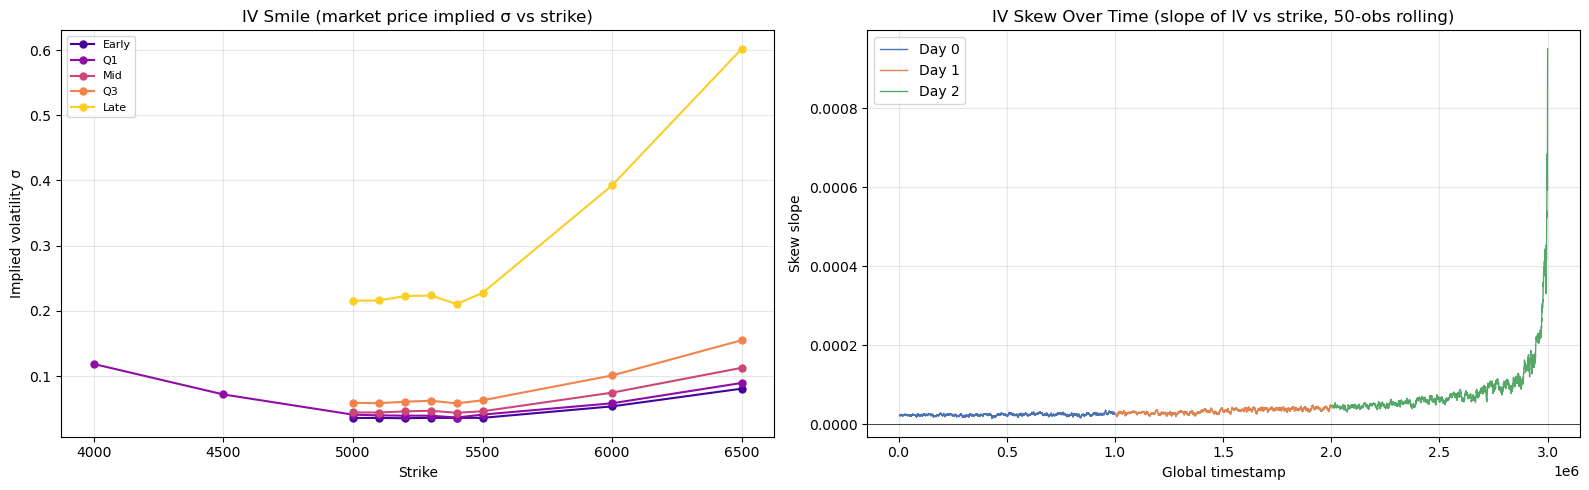

In [5]:
# IV Smile / Skew at multiple snapshots
snap_indices = [500, total_ticks//4, total_ticks//2, 3*total_ticks//4, total_ticks-500]
snap_labels  = ["Early", "Q1", "Mid", "Q3", "Late"]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(snap_indices)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
for idx, lbl, col in zip(snap_indices, snap_labels, colors):
    row_iv = iv_df.iloc[idx]
    ivs    = [row_iv.get(f"IV_{K}", np.nan) for K in STRIKES]
    ax1.plot(STRIKES, ivs, "o-", color=col, label=lbl, lw=1.5, ms=5)

ax1.set_title("IV Smile (market price implied σ vs strike)")
ax1.set_xlabel("Strike"); ax1.set_ylabel("Implied volatility σ")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# Skew: slope of IV across strikes (linear fit)
skews = []
for i in range(len(iv_df)):
    row_iv = iv_df.iloc[i]
    ivs = np.array([row_iv.get(f"IV_{K}", np.nan) for K in STRIKES])
    valid = ~np.isnan(ivs)
    if valid.sum() >= 3:
        coeffs = np.polyfit(np.array(STRIKES)[valid], ivs[valid], 1)
        skews.append(coeffs[0])
    else:
        skews.append(np.nan)
iv_df["skew"] = skews

for d in [0,1,2]:
    sub = iv_df[iv_df["day"] == d]
    ax2.plot(sub["global_ts"], sub["skew"].rolling(50).mean(),
             color=day_colors[d], lw=1.0, label=f"Day {d}")
ax2.axhline(0, color="black", lw=0.5)
ax2.set_title("IV Skew Over Time (slope of IV vs strike, 50-obs rolling)")
ax2.set_xlabel("Global timestamp"); ax2.set_ylabel("Skew slope")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5 — IV Surface (Strike × Time)

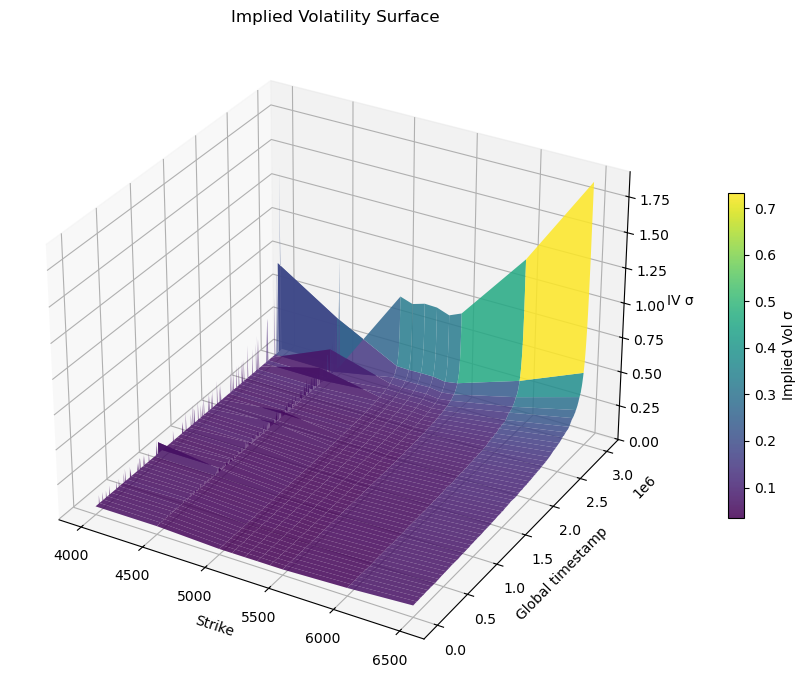

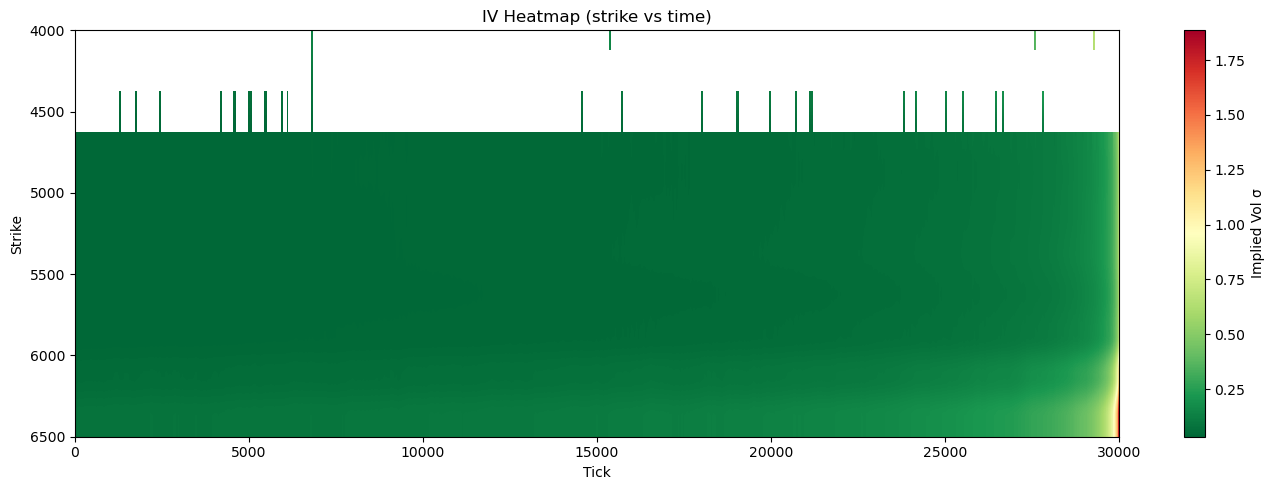

In [6]:
# IV Surface — strike x time
fig = plt.figure(figsize=(14, 7))
ax3d = fig.add_subplot(111, projection="3d")

X_st = np.array(STRIKES)
Y_ts = iv_df["global_ts"].values[::50]   # downsample for speed
Z = np.array([[iv_df[f"IV_{K}"].values[::50][i] for K in STRIKES]
               for i in range(len(Y_ts))])

Xg, Yg = np.meshgrid(X_st, Y_ts)
mask = ~np.isnan(Z)
Z_plot = np.where(mask, Z, np.nanmedian(Z))

surf = ax3d.plot_surface(Xg, Yg, Z_plot, cmap="viridis", alpha=0.85,
                         linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax3d, shrink=0.5, label="Implied Vol σ")
ax3d.set_xlabel("Strike"); ax3d.set_ylabel("Global timestamp")
ax3d.set_zlabel("IV σ"); ax3d.set_title("Implied Volatility Surface")
plt.tight_layout(); plt.show()

# Heatmap version (easier to read)
fig2, ax2 = plt.subplots(figsize=(14, 5))
hm_data = iv_df[iv_cols].values[::50].T   # shape (n_strikes, n_times)
im = ax2.imshow(hm_data, aspect="auto", cmap="RdYlGn_r",
                extent=[0, total_ticks, STRIKES[-1], STRIKES[0]])
plt.colorbar(im, ax=ax2, label="Implied Vol σ")
ax2.set_title("IV Heatmap (strike vs time)"); ax2.set_xlabel("Tick"); ax2.set_ylabel("Strike")
plt.tight_layout(); plt.show()


## 6 — Historical Realised Vol vs Implied Vol

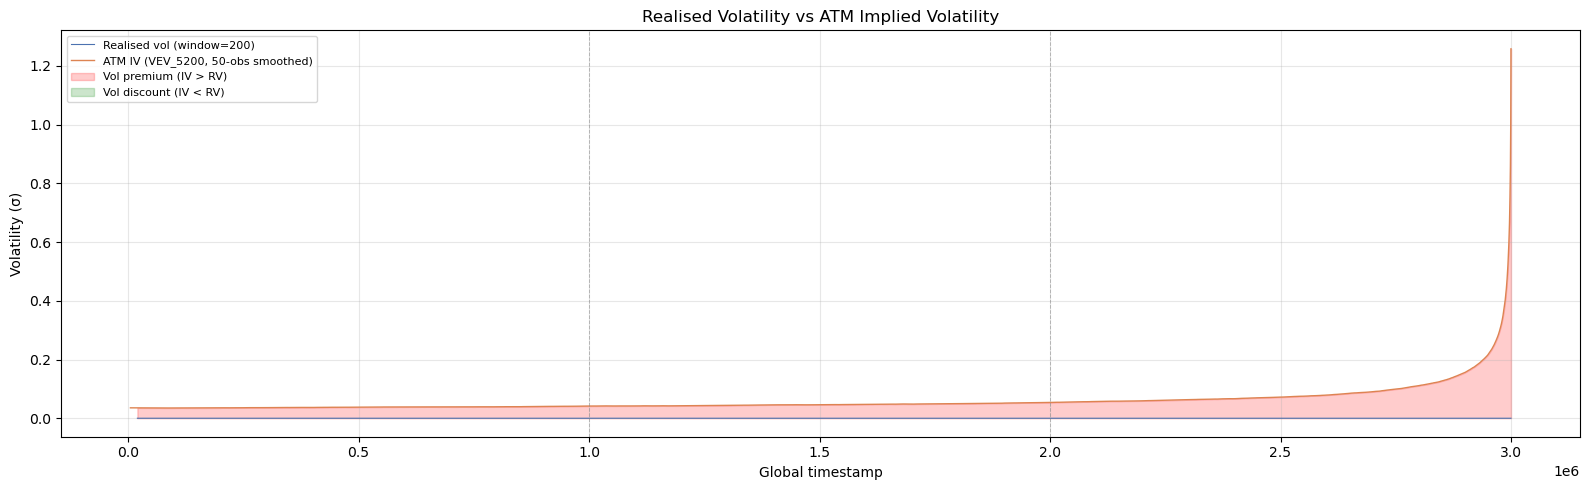

Mean vol premium (IV - RV): 0.0604
Vol premium > 0 (IV > RV):  99.3% of ticks


In [7]:
# Realised vol of underlying vs ATM implied vol
WINDOW_RV = 200
S_series = wide[UNDERLYING]
rv = S_series.diff().rolling(WINDOW_RV).std()   # realised vol (price units)
rv_norm = rv / S_series                          # normalise to "sigma" units

# ATM IV ≈ VEV_5200 or VEV_5000 (closest to spot)
atm_iv = iv_df["IV_5200"].rolling(50).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(wide["global_ts"], rv_norm,  label=f"Realised vol (window={WINDOW_RV})", color="#4C72B0", lw=0.8)
ax.plot(wide["global_ts"], atm_iv,   label="ATM IV (VEV_5200, 50-obs smoothed)", color="#DD8452", lw=1.0)
vol_premium = atm_iv - rv_norm
ax.fill_between(wide["global_ts"], rv_norm, atm_iv,
                where=(atm_iv > rv_norm), alpha=0.2, color="red",   label="Vol premium (IV > RV)")
ax.fill_between(wide["global_ts"], rv_norm, atm_iv,
                where=(atm_iv < rv_norm), alpha=0.2, color="green", label="Vol discount (IV < RV)")
for i in range(1, 3):
    ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
ax.set_title("Realised Volatility vs ATM Implied Volatility")
ax.set_xlabel("Global timestamp"); ax.set_ylabel("Volatility (σ)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Mean vol premium (IV - RV): {vol_premium.mean():.4f}")
print(f"Vol premium > 0 (IV > RV):  {(vol_premium > 0).mean()*100:.1f}% of ticks")


## 7 — Intrinsic vs Time Value Decomposition

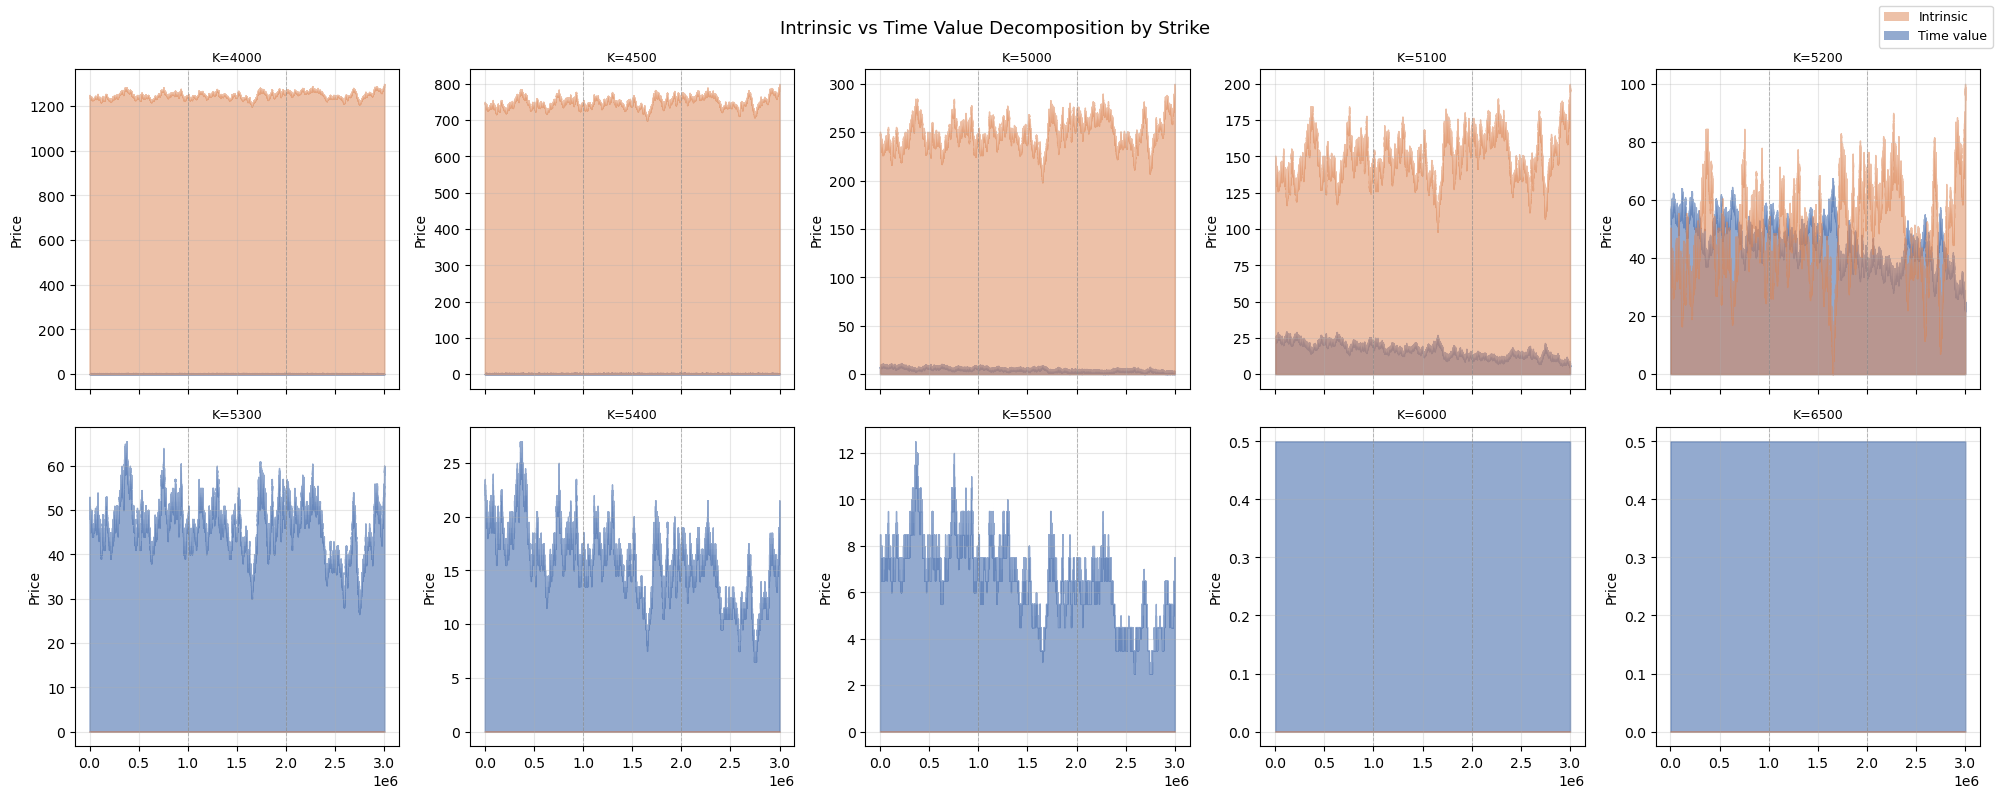

In [8]:
# Time value decay across 3 days for each strike
# Compute time value = max(market_price - intrinsic, 0)
fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)
axes = axes.flatten()
S_arr = wide[UNDERLYING].values

for ax, K in zip(axes, STRIKES):
    col = f"VEV_{K}"
    if col not in wide.columns:
        continue
    C_arr      = wide[col].values
    intrinsic  = np.maximum(S_arr - K, 0)
    time_val   = np.maximum(C_arr - intrinsic, 0)

    ax.fill_between(wide["global_ts"], time_val, alpha=0.6, color="#4C72B0")
    ax.fill_between(wide["global_ts"], intrinsic, alpha=0.5, color="#DD8452")
    ax.set_title(f"K={K}", fontsize=9)
    ax.set_ylabel("Price"); ax.grid(True, alpha=0.3)
    for i in range(1, 3):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)

from matplotlib.patches import Patch
legend_el = [Patch(facecolor="#DD8452", alpha=0.5, label="Intrinsic"),
             Patch(facecolor="#4C72B0", alpha=0.6, label="Time value")]
fig.legend(handles=legend_el, loc="upper right", fontsize=9)
fig.suptitle("Intrinsic vs Time Value Decomposition by Strike", fontsize=13)
plt.tight_layout(); plt.show()


## 8 — Greeks (Δ, Γ, V, Θ)

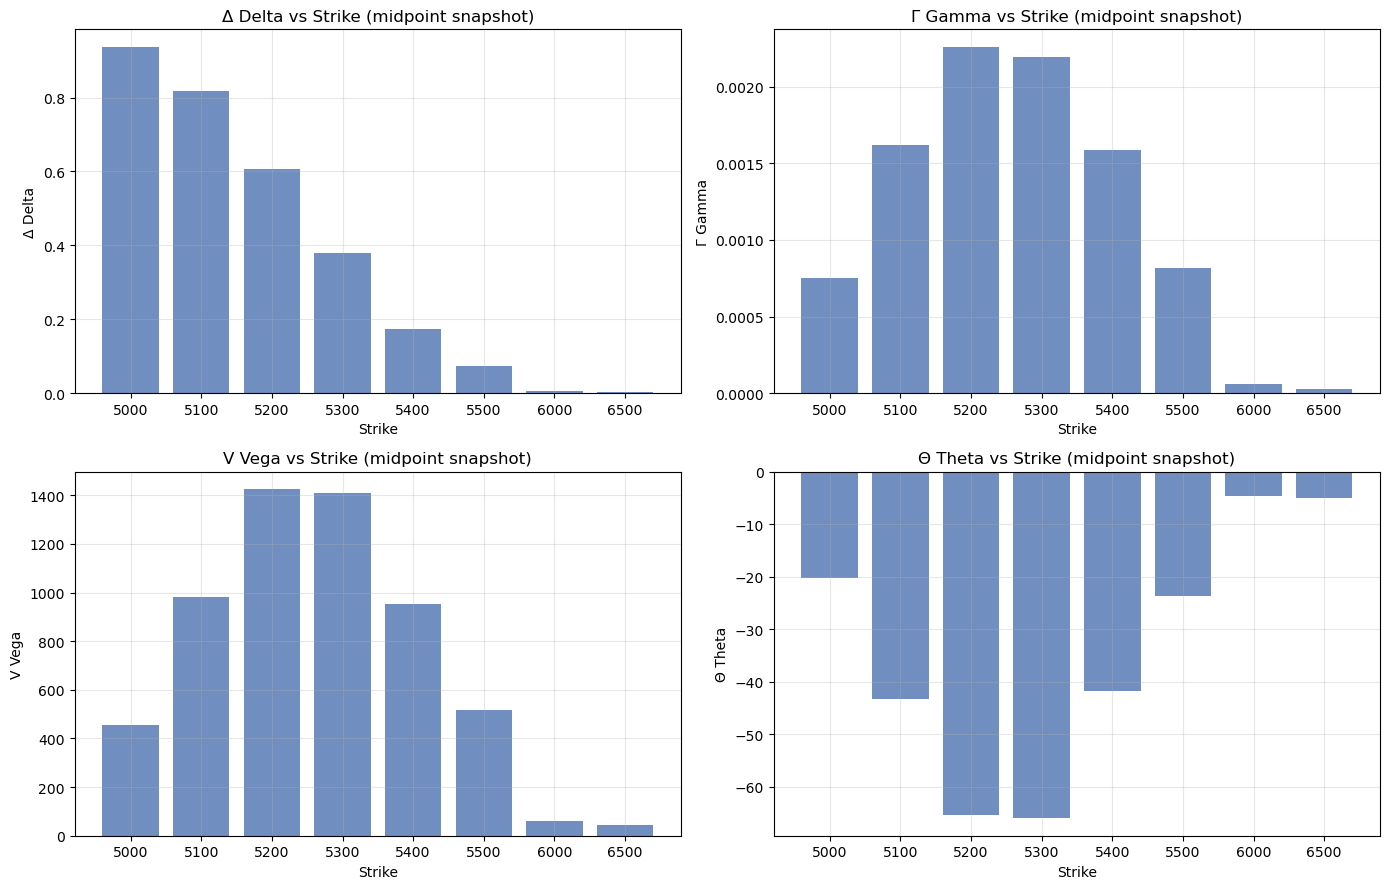

In [9]:
# Compute BS Greeks for all strikes over time (downsample for speed)
STEP = 50
idx_sub = wide.index[::STEP]
greek_rows = []
for i in idx_sub:
    row = wide.loc[i]
    S_v = row[UNDERLYING]; T_v = row["T"]
    for K in STRIKES:
        iv_val = iv_df.loc[i, f"IV_{K}"]
        if np.isnan(iv_val):
            continue
        greek_rows.append({
            "global_ts": row["global_ts"], "day": row["day"], "K": K,
            "delta": bs_delta(S_v, K, T_v, iv_val),
            "gamma": bs_gamma(S_v, K, T_v, iv_val),
            "vega":  bs_vega (S_v, K, T_v, iv_val),
            "theta": bs_theta(S_v, K, T_v, iv_val),
        })
greeks = pd.DataFrame(greek_rows)

# Plot Greeks vs strike at fixed snapshot
snap_ts = wide["global_ts"].iloc[total_ticks // 2]
snap_g  = greeks[greeks["global_ts"] == greeks["global_ts"].iloc[
                 greeks["global_ts"].searchsorted(snap_ts)]]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, gname, ylabel in zip(axes.flatten(),
                              ["delta","gamma","vega","theta"],
                              ["Δ Delta","Γ Gamma","V Vega","Θ Theta"]):
    ax.bar(snap_g["K"].astype(str), snap_g[gname], color="#4C72B0", alpha=0.8)
    ax.set_title(f"{ylabel} vs Strike (midpoint snapshot)")
    ax.set_xlabel("Strike"); ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 9 — Greeks Heatmap (Strike × Time)

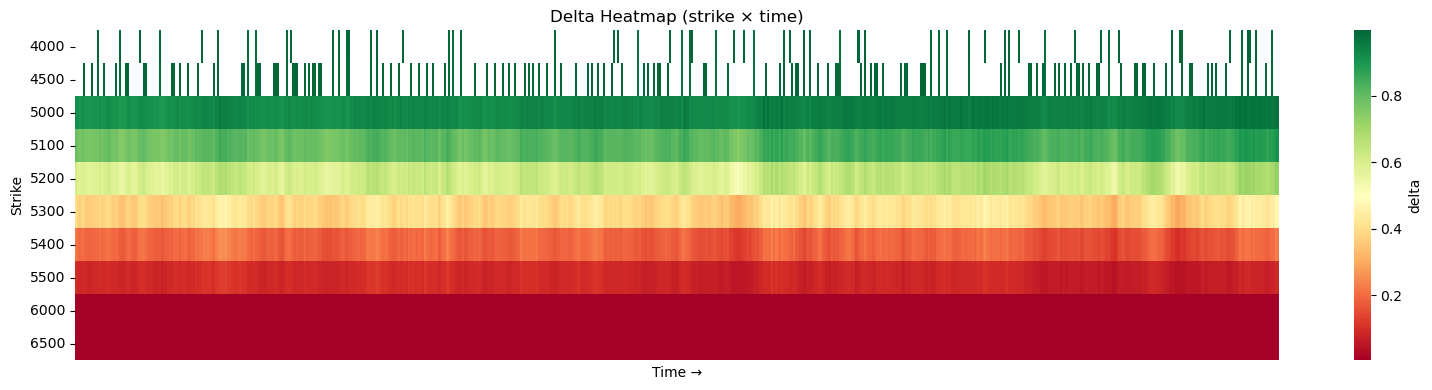

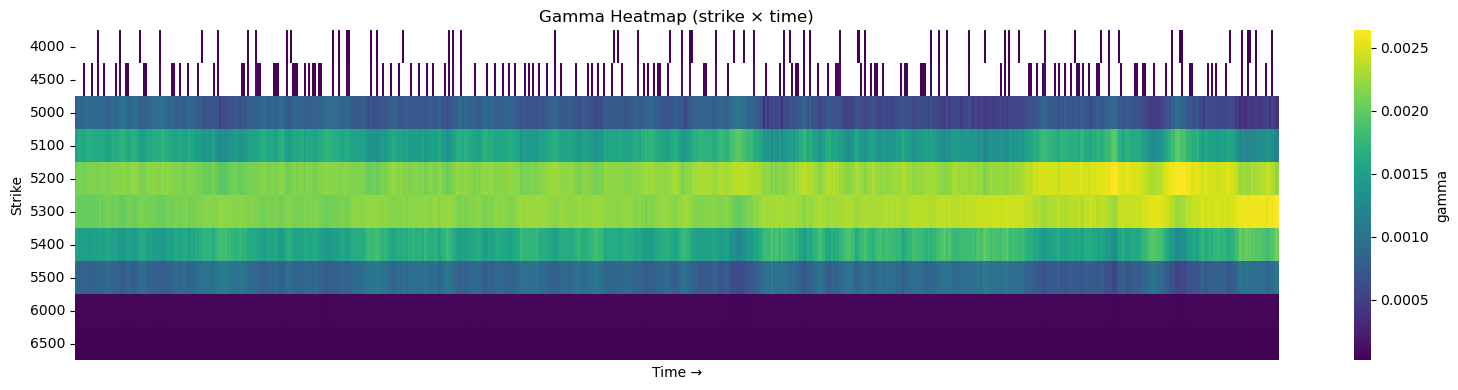

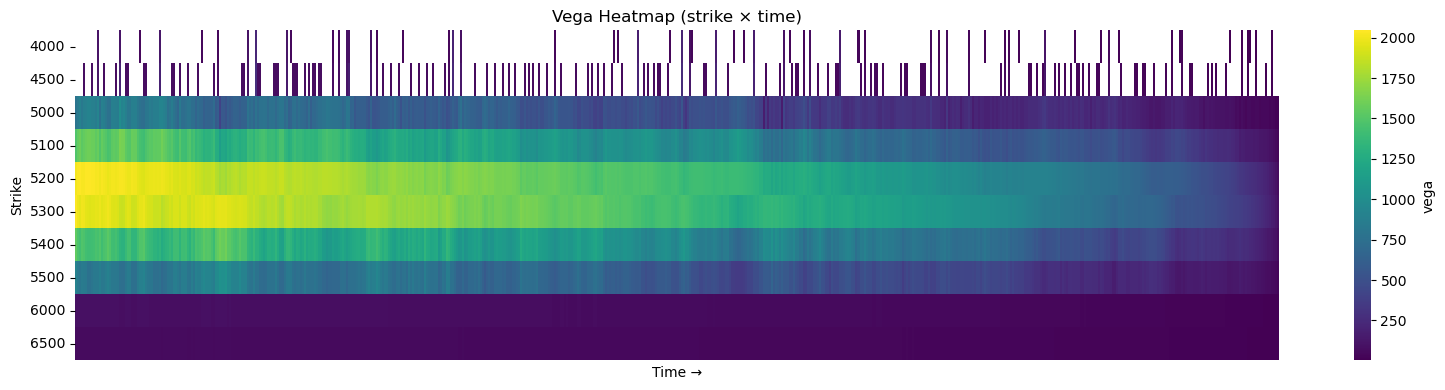

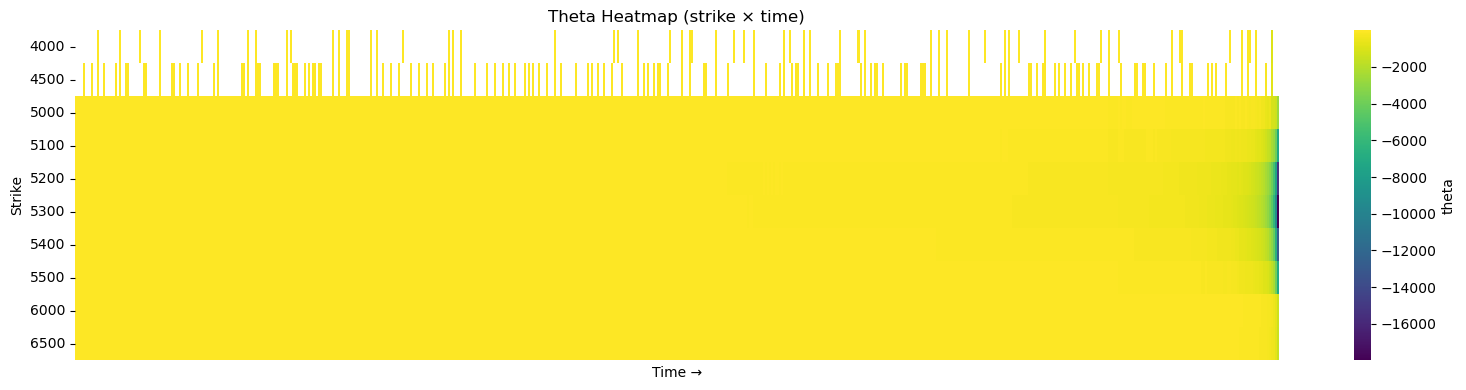

In [10]:
import seaborn as sns

for gname in ["delta", "gamma", "vega", "theta"]:
    pivot = greeks.pivot_table(index="K", columns="global_ts", values=gname, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(16, 4))
    sns.heatmap(pivot, ax=ax, cmap="RdYlGn" if gname == "delta" else "viridis",
                cbar_kws={"label": gname}, xticklabels=False)
    ax.set_title(f"{gname.title()} Heatmap (strike × time)")
    ax.set_ylabel("Strike"); ax.set_xlabel("Time →")
    plt.tight_layout(); plt.show()


## 10 — Delta-Hedging P&L Simulation

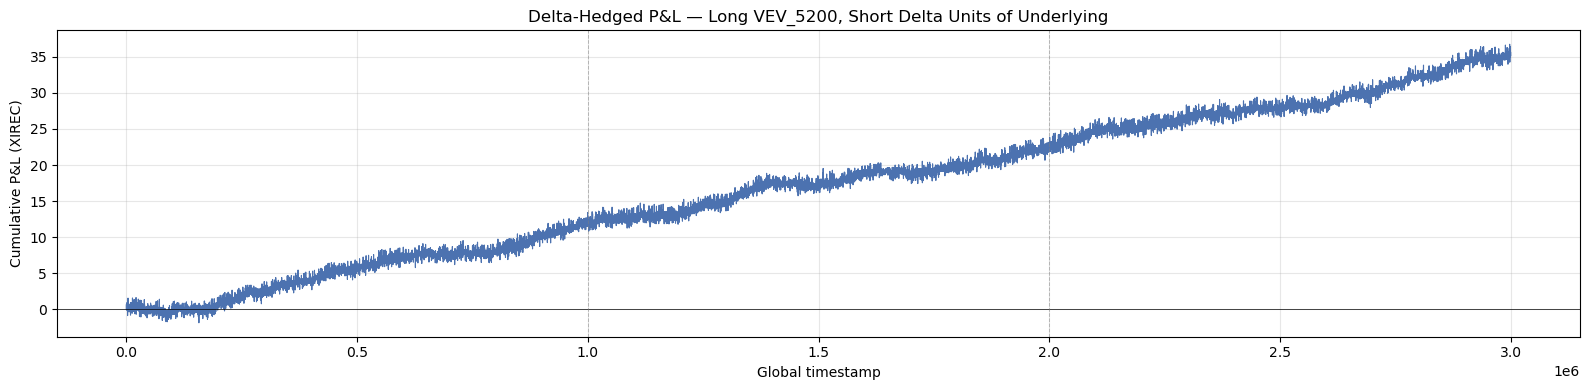

Final delta-hedge P&L: 35.17


In [11]:
# Simulate delta-neutral position: long 1 ATM option, short delta units of underlying
K_HEDGE = 5200
if f"VEV_{K_HEDGE}" in wide.columns:
    hedge_pnl = [0.0]
    prev_opt_price = wide[f"VEV_{K_HEDGE}"].iloc[0]
    prev_und_price = wide[UNDERLYING].iloc[0]
    prev_delta     = bs_delta(prev_und_price, K_HEDGE,
                              wide["T"].iloc[0],
                              iv_df[f"IV_{K_HEDGE}"].iloc[0] or 0.15)
    for i in range(1, len(wide)):
        C_now = wide[f"VEV_{K_HEDGE}"].iloc[i]
        S_now = wide[UNDERLYING].iloc[i]
        if np.isnan(C_now) or np.isnan(S_now):
            hedge_pnl.append(hedge_pnl[-1])
            continue
        opt_pnl = C_now - prev_opt_price
        und_pnl = prev_delta * (prev_und_price - S_now)  # short delta
        hedge_pnl.append(hedge_pnl[-1] + opt_pnl + und_pnl)

        iv_now = iv_df[f"IV_{K_HEDGE}"].iloc[i]
        prev_delta     = bs_delta(S_now, K_HEDGE, wide["T"].iloc[i],
                                  iv_now if not np.isnan(iv_now) else 0.15)
        prev_opt_price = C_now; prev_und_price = S_now

    fig, ax = plt.subplots(figsize=(16, 4))
    ax.plot(wide["global_ts"], hedge_pnl, color="#4C72B0", lw=0.8)
    ax.axhline(0, color="black", lw=0.5)
    for i in range(1, 3):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.set_title(f"Delta-Hedged P&L — Long VEV_{K_HEDGE}, Short Delta Units of Underlying")
    ax.set_xlabel("Global timestamp"); ax.set_ylabel("Cumulative P&L (XIREC)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"Final delta-hedge P&L: {hedge_pnl[-1]:.2f}")


## 11 — Mean Reversion of IV (ADF + Half-Life)

 Strike  ADF stat  p-value  Stationary (p<0.05) Half-life (ticks)
   4000   -5.7125   0.0000                 True                 ∞
   4500  -10.3550   0.0000                 True                 ∞
   5000    2.8019   1.0000                False                 ∞
   5100   14.0269   1.0000                False                 ∞
   5200  -10.9051   0.0000                 True                 ∞
   5300  -18.3970   0.0000                 True                 ∞
   5400  -16.9133   0.0000                 True                 ∞
   5500    8.6774   1.0000                False                 ∞
   6000  -14.4666   0.0000                 True                 ∞
   6500   -2.6724   0.0789                False                 ∞


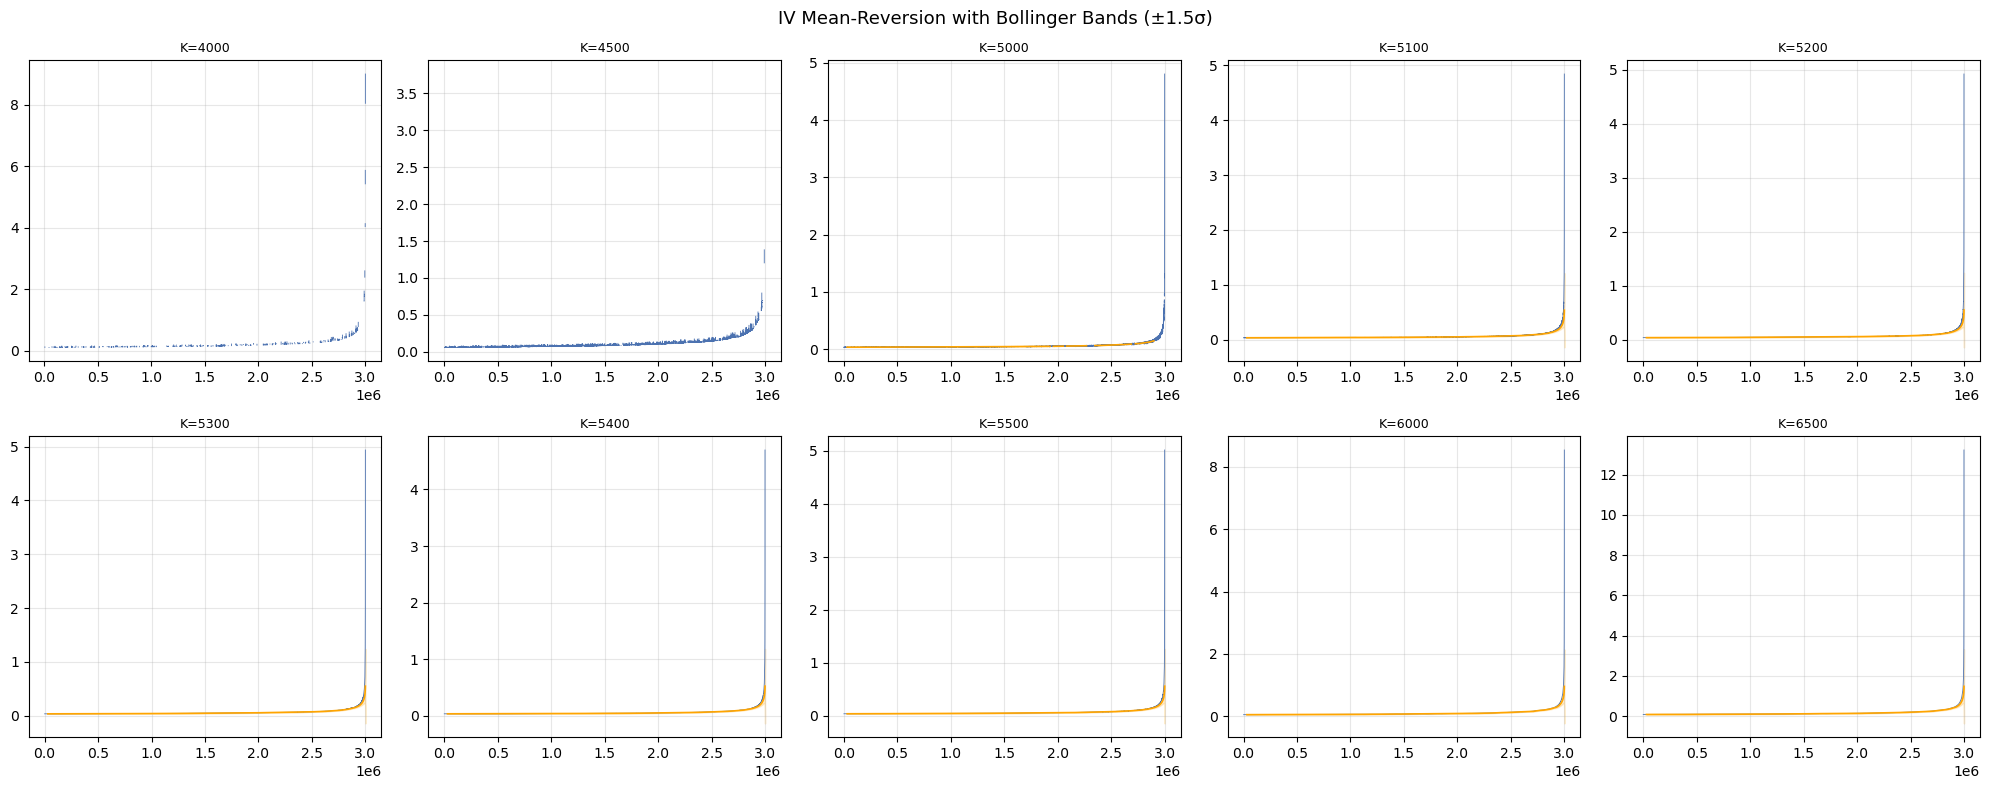

In [12]:
from statsmodels.tsa.stattools import adfuller

def half_life_ar1(series):
    s = series.dropna()
    if len(s) < 20:
        return np.nan
    lag   = s.shift(1).dropna()
    delta = (s - s.shift(1)).dropna()
    n     = min(len(lag), len(delta))
    lag, delta = lag.iloc[-n:].values, delta.iloc[-n:].values
    X = np.column_stack([np.ones(n), lag])
    beta = np.linalg.lstsq(X, delta, rcond=None)[0][1]
    return -np.log(2) / beta if beta < 0 else np.inf

results = []
for K in STRIKES:
    iv_series = iv_df[f"IV_{K}"].dropna()
    if len(iv_series) < 50:
        continue
    adf = adfuller(iv_series, autolag="AIC")
    hl  = half_life_ar1(iv_df[f"IV_{K}"])
    results.append({"Strike": K, "ADF stat": round(adf[0],4),
                    "p-value": round(adf[1],4),
                    "Stationary (p<0.05)": adf[1] < 0.05,
                    "Half-life (ticks)": round(hl,1) if np.isfinite(hl) else "∞"})
print(pd.DataFrame(results).to_string(index=False))

# IV with Bollinger bands
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
ROLL = 300
for ax, K in zip(axes.flatten(), STRIKES):
    s = iv_df[f"IV_{K}"]
    mn = s.rolling(ROLL).mean(); std = s.rolling(ROLL).std()
    ax.plot(iv_df["global_ts"], s,  lw=0.6, color="#4C72B0", label="IV")
    ax.plot(iv_df["global_ts"], mn, lw=1.2, color="orange",  label=f"Mean({ROLL})")
    ax.fill_between(iv_df["global_ts"], mn-1.5*std, mn+1.5*std, alpha=0.2, color="orange")
    ax.set_title(f"K={K}", fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("IV Mean-Reversion with Bollinger Bands (±1.5σ)", fontsize=13)
plt.tight_layout(); plt.show()


## 12 — IV Scalping Signal & Backtest

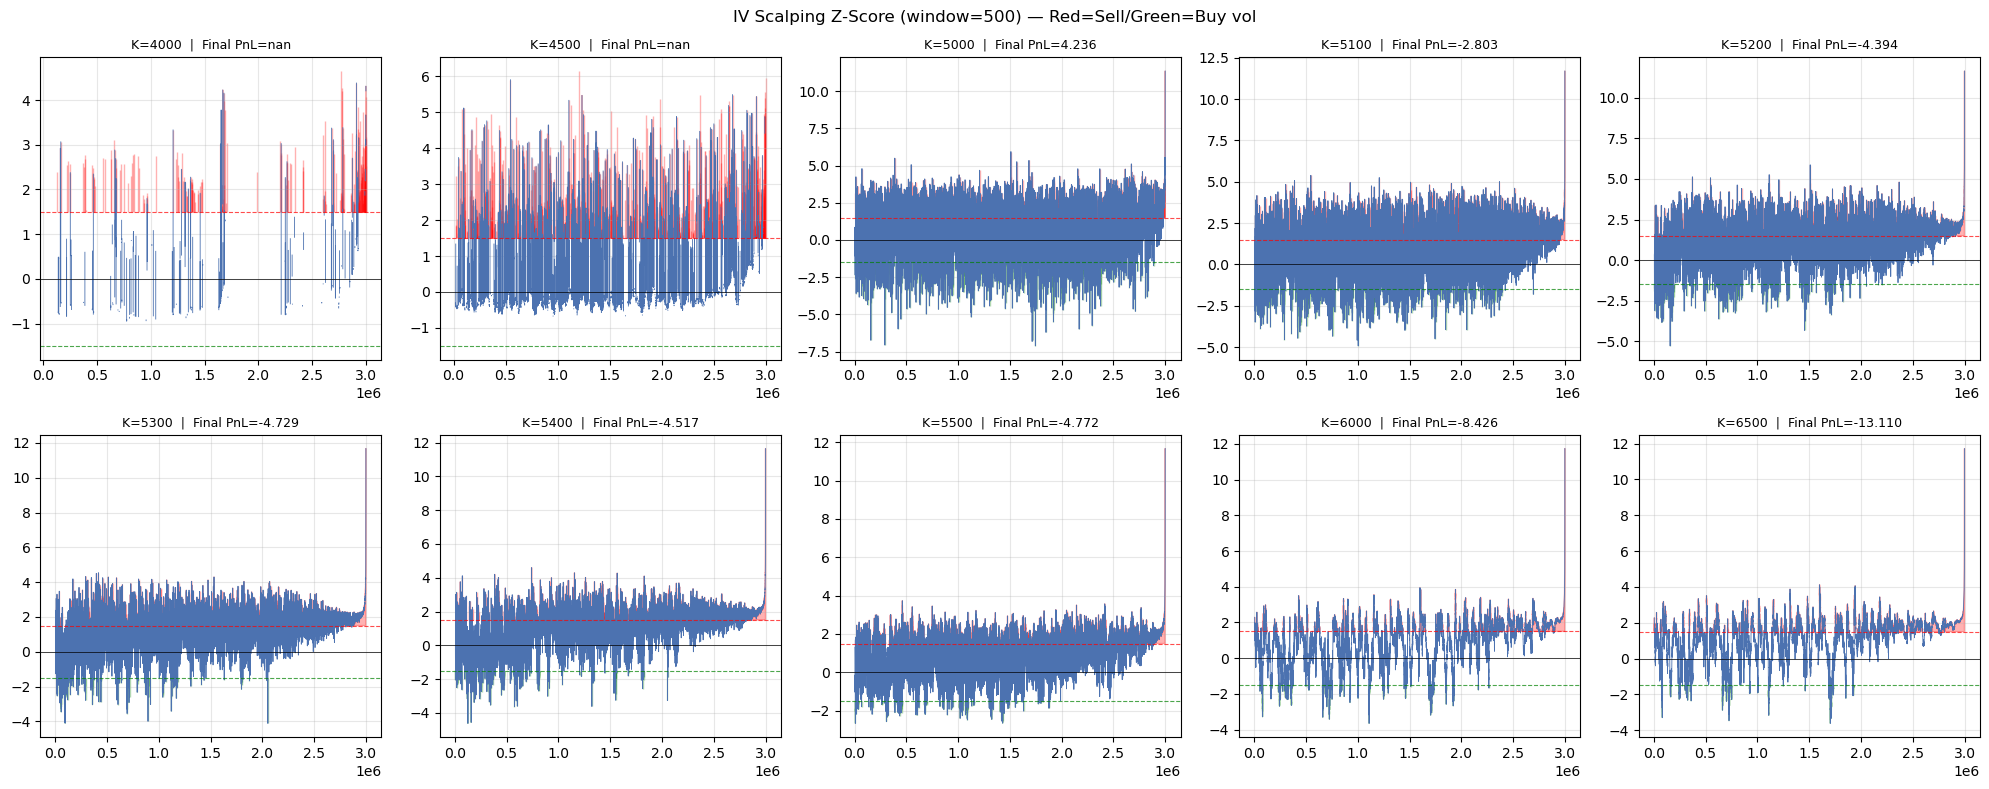

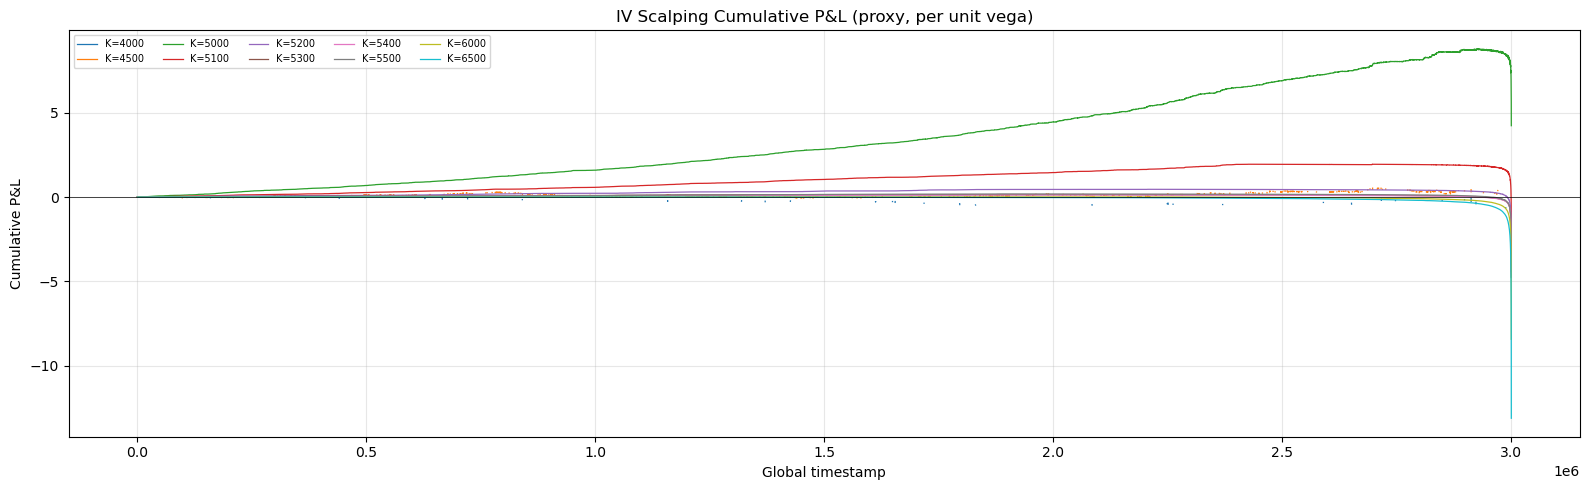

In [13]:
# IV Scalping Signal — Z-score based vol entry/exit
ROLL_SIG = 500
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

all_pnl = {}
for ax, K in zip(axes.flatten(), STRIKES):
    s   = iv_df[f"IV_{K}"]
    mn  = s.rolling(ROLL_SIG, min_periods=50).mean()
    std = s.rolling(ROLL_SIG, min_periods=50).std()
    z   = (s - mn) / std.replace(0, np.nan)

    # Signal: +1 = buy vol (z < -1.5), -1 = sell vol (z > +1.5), 0 = flat
    sig = np.where(z < -1.5, 1, np.where(z > 1.5, -1, np.nan))
    sig = pd.Series(sig, index=s.index).ffill().fillna(0)

    # P&L proxy: signal × next tick IV change (vol is "traded" at current IV)
    pnl = (sig.shift(1) * s.diff()).cumsum()
    all_pnl[K] = pnl

    ax.plot(iv_df["global_ts"], z, lw=0.6, color="#4C72B0")
    ax.fill_between(iv_df["global_ts"], z, 1.5,
                    where=(z > 1.5), alpha=0.3, color="red",   label="Sell vol")
    ax.fill_between(iv_df["global_ts"], z, -1.5,
                    where=(z < -1.5), alpha=0.3, color="green", label="Buy vol")
    ax.axhline(0,    color="black", lw=0.5)
    ax.axhline( 1.5, color="red",   ls="--", lw=0.8, alpha=0.7)
    ax.axhline(-1.5, color="green", ls="--", lw=0.8, alpha=0.7)
    ax.set_title(f"K={K}  |  Final PnL={pnl.iloc[-1]:.3f}", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"IV Scalping Z-Score (window={ROLL_SIG}) — Red=Sell/Green=Buy vol", fontsize=12)
plt.tight_layout(); plt.show()

# Cumulative P&L for all strikes
fig2, ax2 = plt.subplots(figsize=(16, 5))
colors_k = plt.cm.tab10(np.linspace(0, 1, len(STRIKES)))
for (K, pnl), col in zip(all_pnl.items(), colors_k):
    ax2.plot(iv_df["global_ts"], pnl, lw=0.9, color=col, label=f"K={K}")
ax2.axhline(0, color="black", lw=0.5)
ax2.set_title("IV Scalping Cumulative P&L (proxy, per unit vega)")
ax2.set_xlabel("Global timestamp"); ax2.set_ylabel("Cumulative P&L")
ax2.legend(fontsize=7, ncol=5); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 13 — Vol-of-Vol

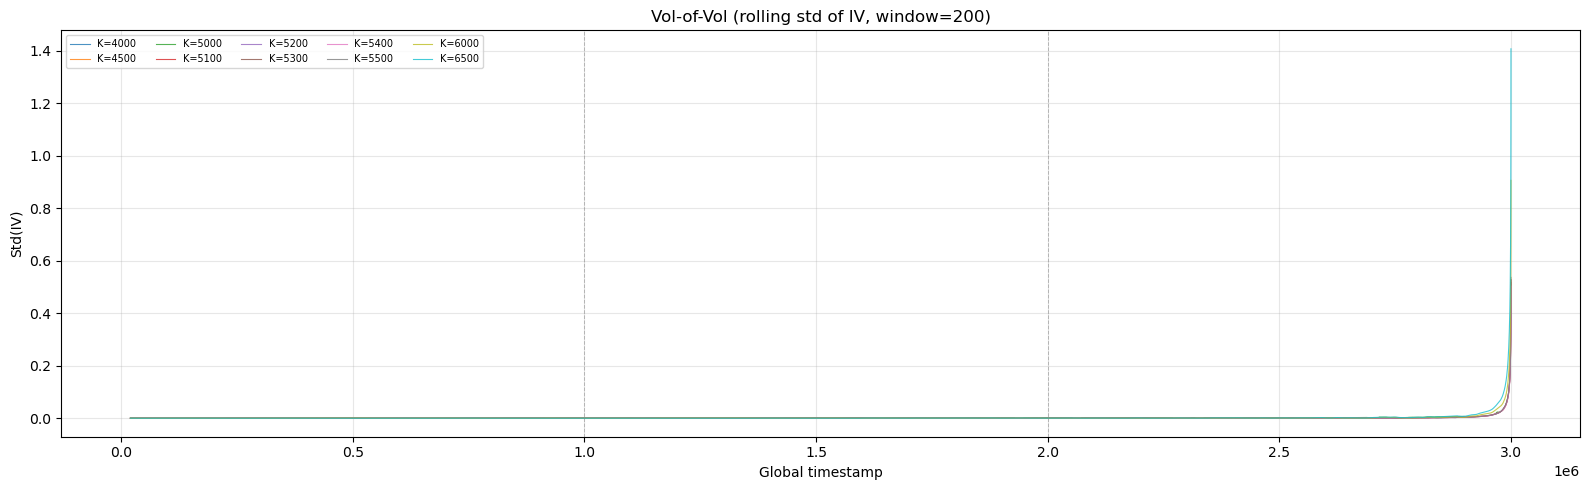

      mean_vov  max_vov
4000       NaN      NaN
4500       NaN      NaN
5000    0.0015   0.0236
5100    0.0015   0.5176
5200    0.0013   0.5273
5300    0.0012   0.5280
5400    0.0012   0.5031
5500    0.0014   0.5366
6000    0.0022   0.9064
6500    0.0031   1.4076


In [14]:
# Vol-of-Vol: rolling std of IV per strike
ROLL_VV = 200
fig, ax = plt.subplots(figsize=(16, 5))
colors_k = plt.cm.tab10(np.linspace(0, 1, len(STRIKES)))
for K, col in zip(STRIKES, colors_k):
    vov = iv_df[f"IV_{K}"].rolling(ROLL_VV).std()
    ax.plot(iv_df["global_ts"], vov, lw=0.8, color=col, label=f"K={K}", alpha=0.8)
for i in range(1, 3):
    ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
ax.set_title(f"Vol-of-Vol (rolling std of IV, window={ROLL_VV})")
ax.set_xlabel("Global timestamp"); ax.set_ylabel("Std(IV)")
ax.legend(fontsize=7, ncol=5); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Summary table
vov_stats = {}
for K in STRIKES:
    vov = iv_df[f"IV_{K}"].rolling(ROLL_VV).std().dropna()
    vov_stats[K] = {"mean_vov": round(vov.mean(),4), "max_vov": round(vov.max(),4)}
print(pd.DataFrame(vov_stats).T.to_string())


## 14 — Arbitrage Checks

In [15]:
# Arbitrage checks
violations = []
for i in range(len(wide)):
    row = wide.iloc[i]
    S_v = row.get(UNDERLYING, np.nan)
    if np.isnan(S_v):
        continue
    # (a) Call spread monotonicity: C(K1) > C(K2) for K1 < K2
    prev_price = None
    for K in STRIKES:
        c = row.get(f"VEV_{K}", np.nan)
        if np.isnan(c):
            prev_price = None; continue
        if prev_price is not None and c > prev_price + 0.5:
            violations.append({"type": "spread_monotonicity",
                                "ts": row["global_ts"], "K": K, "detail": f"C({K})={c:.2f} > C(prev)"})
        prev_price = c
    # (b) Lower bound: C >= max(S-K, 0)
    for K in STRIKES:
        c = row.get(f"VEV_{K}", np.nan)
        lb = max(S_v - K, 0)
        if not np.isnan(c) and c < lb - 0.5:
            violations.append({"type": "lower_bound",
                                "ts": row["global_ts"], "K": K,
                                "detail": f"C={c:.2f} < intrinsic={lb:.2f}"})
    # (c) Convexity (butterfly): C(K1) - 2*C(K2) + C(K3) >= 0
    for j in range(1, len(STRIKES)-1):
        K1, K2, K3 = STRIKES[j-1], STRIKES[j], STRIKES[j+1]
        c1 = row.get(f"VEV_{K1}", np.nan)
        c2 = row.get(f"VEV_{K2}", np.nan)
        c3 = row.get(f"VEV_{K3}", np.nan)
        if not any(np.isnan([c1,c2,c3])):
            bf = c1 - 2*c2 + c3
            if bf < -1.0:
                violations.append({"type": "convexity",
                                    "ts": row["global_ts"], "K_mid": K2,
                                    "detail": f"butterfly={bf:.3f}"})

vdf = pd.DataFrame(violations)
if len(vdf):
    print(f"Total violations: {len(vdf)}")
    print(vdf["type"].value_counts().to_string())
    print(vdf.head(10).to_string(index=False))
else:
    print("No arbitrage violations found — option chain is consistent.")


Total violations: 2568
type
lower_bound    2568
       type      ts    K                        detail
lower_bound  1000.0 4000 C=1246.50 < intrinsic=1247.50
lower_bound  2900.0 4000 C=1241.00 < intrinsic=1246.50
lower_bound  2900.0 4500   C=742.50 < intrinsic=746.50
lower_bound  5800.0 4000 C=1237.50 < intrinsic=1239.00
lower_bound  5800.0 4500   C=738.00 < intrinsic=739.00
lower_bound  8600.0 4000 C=1229.50 < intrinsic=1230.50
lower_bound  8600.0 4500   C=729.50 < intrinsic=730.50
lower_bound  9200.0 4000 C=1231.50 < intrinsic=1233.00
lower_bound  9200.0 4500   C=732.00 < intrinsic=733.00
lower_bound 12500.0 4000 C=1237.50 < intrinsic=1238.50


## 15 — Option Price Time Series

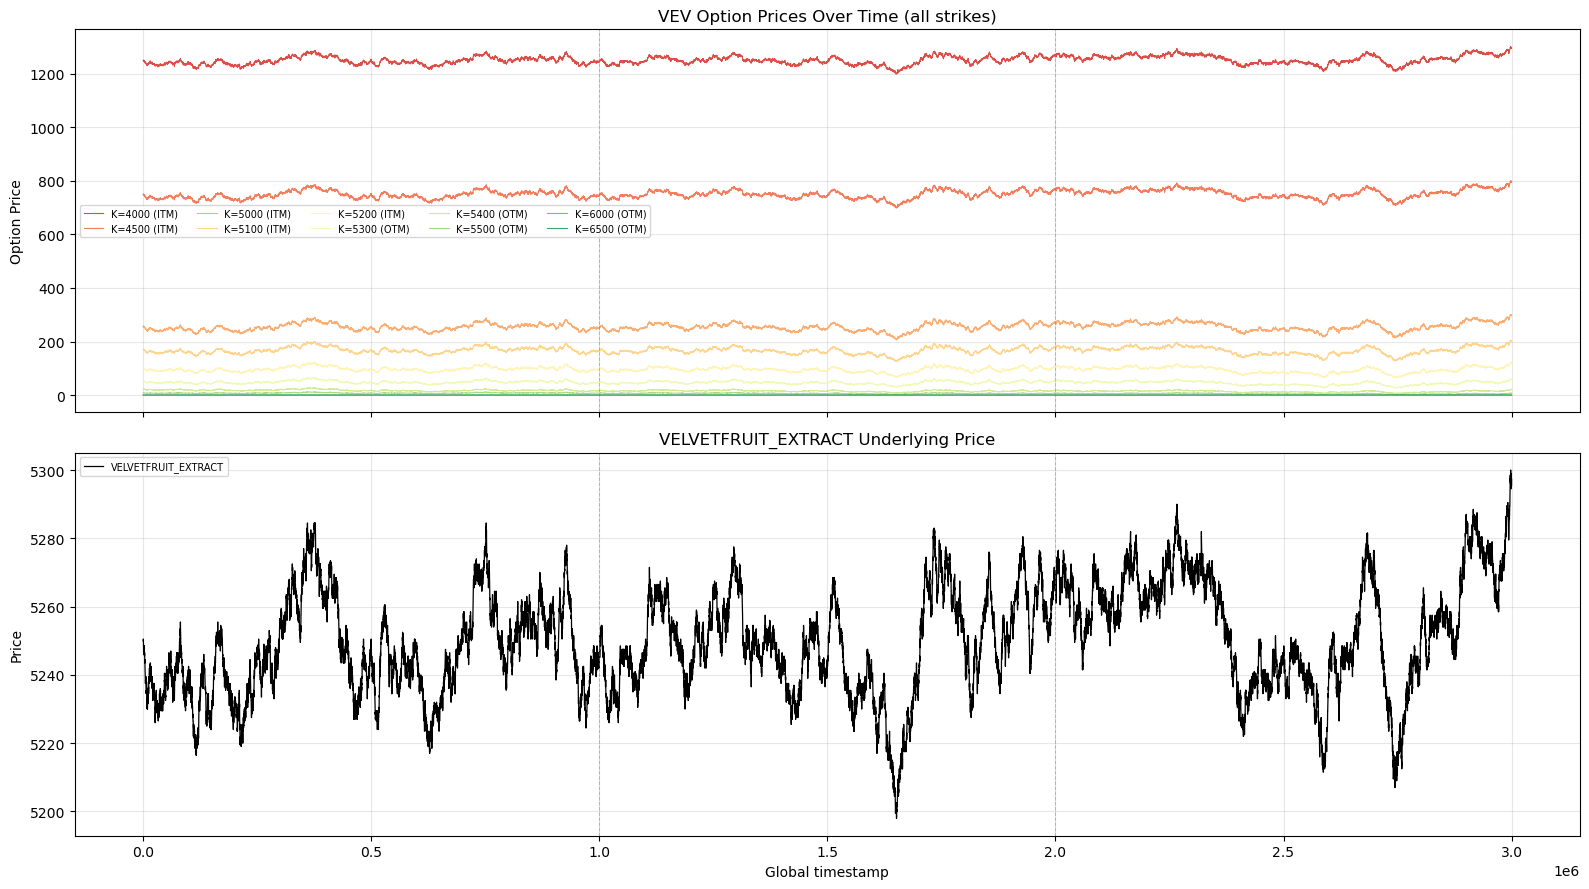

In [16]:
# Option price time series: all 10 strikes, color-coded by moneyness
moneyness_colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(STRIKES)))  # red=OTM, green=ITM

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
S_arr = wide[UNDERLYING].values
mid_S = np.nanmedian(S_arr)

for K, col in zip(STRIKES, moneyness_colors):
    vcol = f"VEV_{K}"
    if vcol not in wide.columns:
        continue
    label = f"K={K} ({'ITM' if K < mid_S else 'OTM' if K > mid_S else 'ATM'})"
    ax1.plot(wide["global_ts"], wide[vcol], color=col, lw=0.8, alpha=0.85, label=label)

ax2.plot(wide["global_ts"], wide[UNDERLYING], color="black", lw=0.9, label=UNDERLYING)

for ax in (ax1, ax2):
    for i in range(1, 3):
        ax.axvline(i * ticks_per_day, color="grey", ls="--", lw=0.7, alpha=0.5)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7, ncol=5)

ax1.set_title("VEV Option Prices Over Time (all strikes)"); ax1.set_ylabel("Option Price")
ax2.set_title(f"{UNDERLYING} Underlying Price"); ax2.set_ylabel("Price")
ax2.set_xlabel("Global timestamp")
plt.tight_layout(); plt.show()
